# Project 9 -- Tanay Patel

**TA Help:** (for instance) John Smith, Alice Jones, etc., list names of any TAs who helped you

- For example: Help with figuring out how to write a function (describe the tasks that they helped you with)

**Collaboration:** My Friend in CS, My Uncle, Another Student, etc., list names of any other people who helped you

(describe the tasks that they helped you with)
- For example: helped figuring out how to load the dataset.
- Another example: helped debug error with my plot.

**Internet Resources:** Stack Exchange, Stack Overflow, etc.

(describe any information that you learned from internet resources, including the URLs)
- data frames in Pandas versus R from StackOverflow  https://stackoverflow.com/questions/8991709/why-were-pandas-merges-in-python-faster-than-data-table-merges-in-r-in-2012

**ChatGPT, Gemini, Claude, etc:** Any language models or generative AI chatbots that helped you.

(if you used any such tools, please tell us here)
- For example:  I asked ChatGPT how to define a new data frames
- Another example:  Gemini told me how to make a function for sorting my data

- ***Link to AI Chat History***: Please share a link to your chat if you used AI (ex. ChatGPT Shared Links)
**OVERALL MESSAGE:** Any time that you used anything except your brain to solve the questions in these projects, you need to disclose such resources at the start of the project, with details about your usage of the tools.

**YOUR OWN WORK:** Even when you utilize other resources, do NOT just copy and paste.  Write all explanations in your own words, using several sentences in English, which are understandable and which you wrote (and did not just copy and paste).

## Question 1

In [1]:
import pandas as pd
orders = pd.read_csv("/anvil/projects/tdm/data/restaurant/orders.csv")
pd.set_option("display.max_columns", None)

/tmp/ipykernel_653/3466877711.py:2: DtypeWarning: Columns (15,16,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  orders = pd.read_csv("/anvil/projects/tdm/data/restaurant/orders.csv")


In [2]:
orders["created_at"] = pd.to_datetime(orders["created_at"])

In [3]:
orders["num_day_of_the_week"] = orders["created_at"].dt.dayofweek
orders["day_of_the_week"] = orders["created_at"].dt.day_name()

In [4]:
orders[["created_at", "num_day_of_the_week", "day_of_the_week"]].head()

,created_at,num_day_of_the_week,day_of_the_week
0,2019-08-01 05:30:16,3,Thursday
1,2019-08-01 05:31:10,3,Thursday
2,2019-08-01 05:31:33,3,Thursday
3,2019-08-01 05:34:54,3,Thursday
4,2019-08-01 05:35:51,3,Thursday


## 1.2
The datetime module is useful because it allows us to convert string dates into actual date objects and easily extract information like day, month, or year. This makes it much easier to analyze time-based patterns in the data.

## 1.3
Yes, the day name matches the correct numerical day value in each row, where Monday corresponds to 0 and Sunday corresponds to 6.

In question 1, we read in the Restaurant Orders dataset using pandas and converted the created_at column into datetime format so that it could be used for time-based analysis. Then we created two new columns, one containing the numerical day of the week and the other containing the name of the day of the week. After that, we displayed these new columns alongside the created_at column to confirm that the values matched correctly.

## Question 2

In [5]:
orders["month"] = orders["created_at"].dt.month_name()
orders["year"] = orders["created_at"].dt.year

orders["month"].value_counts()
orders["year"].value_counts()

year
2019    93795
2020    41508
Name: count, dtype: int64

In [6]:
orders["created_at"].min(), orders["created_at"].max()

(Timestamp('2019-05-10 20:59:58'), Timestamp('2020-02-29 23:52:14'))

In [7]:
monthly_items = orders.groupby("month")["item_count"].sum()
monthly_items

month
August       23853.0
December     47479.0
February     51197.0
January      40410.0
July         27296.0
June         27839.0
May              0.0
November     43102.0
October      31527.0
September    16098.0
Name: item_count, dtype: float64

In [8]:
year_month_items = orders.groupby(["year", "month"])["item_count"].sum()

year_month_items.unstack()

month,August,December,February,January,July,June,May,November,October,September
year,,,,,,,,,,
2019,23853.0,47479.0,NaN,NaN,27296.0,27839.0,0.0,43102.0,31527.0,16098.0
2020,NaN,NaN,51197.0,40410.0,NaN,NaN,NaN,NaN,NaN,NaN


In question 2, we created new columns for the month and year from the created_at column using datetime functions. Then we used .value_counts() to examine how the data was distributed across different months and years. After that, we used .groupby() to calculate the total item_count for each month and also grouped by both year and month to see how the orders were distributed across time.

## Question 3

In [9]:
import pandas as pd

flights = pd.read_csv("/anvil/projects/tdm/data/flights/subset/1997.csv")

flights["full_dates"] = pd.to_datetime(
    flights.rename(columns={
        "Year": "year",
        "Month": "month",
        "DayofMonth": "day"
    })[["year", "month", "day"]]
)

flights[["Year", "Month", "DayofMonth", "full_dates"]].head()

,Year,Month,DayofMonth,full_dates
0,1997,1,28,1997-01-28
1,1997,1,29,1997-01-29
2,1997,1,30,1997-01-30
3,1997,1,31,1997-01-31
4,1997,1,14,1997-01-14


In [10]:
flights["depHour"] = flights["DepTime"] // 100
flights["depMinute"] = flights["DepTime"] % 100

flights["depHour"] = pd.to_timedelta(flights["depHour"], unit="h")
flights["depMinute"] = pd.to_timedelta(flights["depMinute"], unit="m")

flights[["DepTime", "depHour", "depMinute"]].head()

,DepTime,depHour,depMinute
0,1615.0,0 days 16:00:00,0 days 00:15:00
1,1624.0,0 days 16:00:00,0 days 00:24:00
2,1626.0,0 days 16:00:00,0 days 00:26:00
3,1628.0,0 days 16:00:00,0 days 00:28:00
4,1503.0,0 days 15:00:00,0 days 00:03:00


In [11]:
flights["date_times"] = flights["full_dates"] + flights["depHour"] + flights["depMinute"]

flights[["full_dates", "depHour", "depMinute", "date_times"]].head()

,full_dates,depHour,depMinute,date_times
0,1997-01-28,0 days 16:00:00,0 days 00:15:00,1997-01-28 16:15:00
1,1997-01-29,0 days 16:00:00,0 days 00:24:00,1997-01-29 16:24:00
2,1997-01-30,0 days 16:00:00,0 days 00:26:00,1997-01-30 16:26:00
3,1997-01-31,0 days 16:00:00,0 days 00:28:00,1997-01-31 16:28:00
4,1997-01-14,0 days 15:00:00,0 days 00:03:00,1997-01-14 15:03:00


In question 3, we read in the 1997 flights dataset and combined the Year, Month, and DayofMonth columns to create a new full_dates column using pd.to_datetime(). Then we extracted the hour and minute values from the DepTime column and converted them into proper time formats using pd.to_timedelta(). Finally, we combined these components to create a new date_times column that contains the full date and time for each flight.

## Question 4

## 4.1
The calendar library is useful when we want to convert numeric month values into readable month names and maintain a proper calendar order for analysis.

In [12]:
import calendar

flights["Month_Names"] = flights["Month"].apply(lambda x: calendar.month_name[x])

month_order = list(calendar.month_name)[1:]

flights["Month_Names"] = pd.Categorical(
    flights["Month_Names"],
    categories=month_order,
    ordered=True
)

In [13]:
bostonDF = flights[flights["Origin"] == "BOS"]

bostonDF["Month_Names"].value_counts(sort=False)

Month_Names
January      8271
February     7371
March        8302
April        8182
May          8278
June         8265
July         8550
August       8504
September    8208
October      8515
November     7851
December     7971
Name: count, dtype: int64

In question 4, we used the calendar library to convert the numeric Month values into readable month names and stored them in a new column called Month_Names. Then we converted this column into a categorical variable with an ordered list of months so that the data would follow the correct calendar order. After that, we created a subset of the data for flights originating from Boston and used .value_counts() to examine how flights were distributed across the months.

## Question 5

In [14]:
import matplotlib.pyplot as plt

phoenixDF = flights[flights["Origin"] == "PHX"]
chicagoDF = flights[flights["Origin"] == "MDW"]
seattleDF = flights[flights["Origin"] == "SEA"]

In [15]:
boston_distance = bostonDF.groupby("Month_Names", observed=True)["Distance"].mean()
phoenix_distance = phoenixDF.groupby("Month_Names", observed=True)["Distance"].mean()
chicago_distance = chicagoDF.groupby("Month_Names", observed=True)["Distance"].mean()
seattle_distance = seattleDF.groupby("Month_Names", observed=True)["Distance"].mean()

In [16]:
my_distances = pd.DataFrame({
    "BOS": boston_distance,
    "PHX": phoenix_distance,
    "MDW": chicago_distance,
    "SEA": seattle_distance
})

my_distances

,BOS,PHX,MDW,SEA
Month_Names,,,,
January,899.699190,751.851651,359.147939,1052.647174
February,893.662461,755.998288,358.540807,1050.157120
March,893.584558,758.414942,359.513528,1054.616615
April,895.018822,750.131354,360.956631,1062.143961
May,895.601836,747.255099,361.489183,1093.356530
June,886.292075,741.510192,361.372528,1144.422355
July,889.224795,743.758962,361.720955,1157.622487
August,892.835842,747.286225,362.785696,1156.308166
September,882.723806,757.445236,363.684281,1111.635785


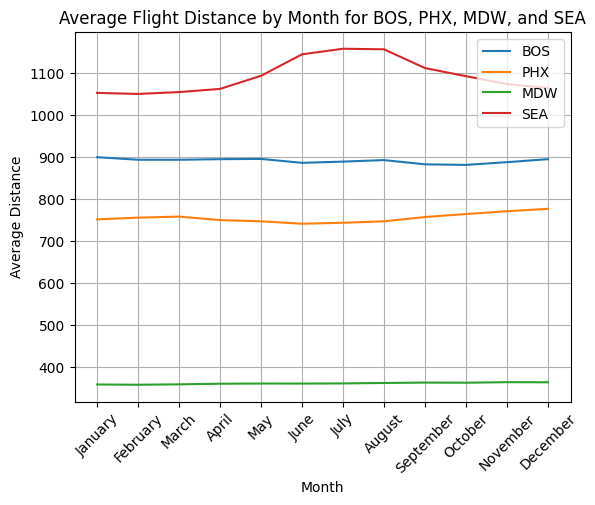

In [17]:
my_distances.plot()

plt.xticks(
    ticks=range(len(my_distances.index)),
    labels=my_distances.index,
    rotation=45
)

plt.xlabel("Month")
plt.ylabel("Average Distance")
plt.title("Average Flight Distance by Month for BOS, PHX, MDW, and SEA")
plt.grid(True)
plt.show()

In question 5, we created separate dataframes for flights originating from Phoenix, Chicago, and Seattle, in addition to the Boston dataframe from the previous question. Then we used .groupby() to calculate the average flight distance for each month for all four locations. After that, we combined these results into a single dataframe and created a plot to compare how the average flight distances vary across the months for each location.

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
